<a href="https://colab.research.google.com/github/RoihansLab/Data-Mining-Project/blob/main/Volcano_eruption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**A. PROBLEM**
What if scientists could anticipate volcanic eruptions as they predict the weather? While determining rain or shine days in advance is more difficult, weather reports become more accurate on shorter time scales. A similar approach with volcanoes could make a big impact. Just one unforeseen eruption can result in tens of thousands of lives lost. If scientists could reliably predict when a volcano will next erupt, evacuations could be more timely and the damage mitigated.

Currently, scientists often identify “time to eruption” by surveying volcanic tremors from seismic signals. In some volcanoes, this intensifies as volcanoes awaken and prepare to erupt. Unfortunately, patterns of seismicity are difficult to interpret. In very active volcanoes, current approaches predict eruptions some minutes in advance, but they usually fail at longer-term predictions.

## **1. Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **B. Preprocessing**

## **2. Data Migration and Integration (Penggabungan & Transformasi Data)**

### **2.1.Load Datasets**

In [ ]:
df_eruption = pd.read_csv("/content/eruptions.csv")
df_event = pd.read_csv("/content/events.csv")
df_volcano = pd.read_csv("/content/volcano.csv")
df_sulfur = pd.read_csv("/content/sulfur.csv")
df_tree_rings = pd.read_csv("/content/tree_rings.csv")

### **2.2. Feature Selection**

#### **2.2.1. Eruption Datasets**

In [ ]:
df_eruption.head(50)

,volcano_number,volcano_name,eruption_number,eruption_category,area_of_activity,vei,start_year,start_month,start_day,evidence_method_dating,end_year,end_month,end_day,latitude,longitude
0,266030,Soputan,22354,Confirmed Eruption,NaN,NaN,2020.0,3.0,23.0,Historical Observations,2020.0,4.0,2.0,1.112,124.737
1,343100,San Miguel,22355,Confirmed Eruption,NaN,NaN,2020.0,2.0,22.0,Historical Observations,2020.0,2.0,22.0,13.434,-88.269
2,233020,"Fournaise, Piton de la",22343,Confirmed Eruption,NaN,NaN,2020.0,2.0,10.0,Historical Observations,2020.0,4.0,6.0,-21.244,55.708
3,345020,Rincon de la Vieja,22346,Confirmed Eruption,NaN,NaN,2020.0,1.0,31.0,Historical Observations,2020.0,4.0,17.0,10.830,-85.324
4,353010,Fernandina,22347,Confirmed Eruption,NaN,NaN,2020.0,1.0,12.0,Historical Observations,2020.0,1.0,12.0,-0.370,-91.550
5,273070,Taal,22344,Confirmed Eruption,NaN,NaN,2020.0,1.0,12.0,Historical Observations,2020.0,1.0,22.0,14.002,120.993
6,282050,Kuchinoerabujima,22345,Confirmed Eruption,NaN,NaN,2020.0,1.0,11.0,Historical Observations,2020.0,4.0,17.0,30.443,130.217
7,241040,Whakaari/White Island,22338,Confirmed Eruption,1978/90 Crater Complex,2.0,2019.0,12.0,9.0,Historical Observations,2019.0,12.0,9.0,-37.520,177.180
8,311060,Semisopochnoi,22341,Confirmed Eruption,NaN,NaN,2019.0,12.0,7.0,Historical Observations,2020.0,3.0,15.0,51.930,179.580
9,284096,Nishinoshima,22340,Confirmed Eruption,NaN,1.0,2019.0,12.0,5.0,Historical Observations,2020.0,4.0,17.0,27.247,140.874


In [ ]:
df_eruption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11178 entries, 0 to 11177
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   volcano_number          11178 non-null  int64  
 1   volcano_name            11178 non-null  object 
 2   eruption_number         11178 non-null  int64  
 3   eruption_category       11178 non-null  object 
 4   area_of_activity        4694 non-null   object 
 5   vei                     8272 non-null   float64
 6   start_year              11177 non-null  float64
 7   start_month             10985 non-null  float64
 8   start_day               10982 non-null  float64
 9   evidence_method_dating  9898 non-null   object 
 10  end_year                4332 non-null   float64
 11  end_month               4329 non-null   float64
 12  end_day                 4326 non-null   float64
 13  latitude                11178 non-null  float64
 14  longitude               11178 non-null

In [ ]:
df_eruption.isnull().sum()

,0
volcano_number,0
volcano_name,0
eruption_number,0
eruption_category,0
area_of_activity,6484
vei,2906
start_year,1
start_month,193
start_day,196
evidence_method_dating,1280


In [ ]:
kolom_inti = [
    'volcano_number',
    'volcano_name',
    'eruption_number',
    'eruption_category',
    'vei',
    'start_year'
]

df_eruption_new = df_eruption[kolom_inti].copy()
df_eruption_new.head(50)

,volcano_number,volcano_name,eruption_number,eruption_category,vei,start_year
0,266030,Soputan,22354,Confirmed Eruption,NaN,2020.0
1,343100,San Miguel,22355,Confirmed Eruption,NaN,2020.0
2,233020,"Fournaise, Piton de la",22343,Confirmed Eruption,NaN,2020.0
3,345020,Rincon de la Vieja,22346,Confirmed Eruption,NaN,2020.0
4,353010,Fernandina,22347,Confirmed Eruption,NaN,2020.0
5,273070,Taal,22344,Confirmed Eruption,NaN,2020.0
6,282050,Kuchinoerabujima,22345,Confirmed Eruption,NaN,2020.0
7,241040,Whakaari/White Island,22338,Confirmed Eruption,2.0,2019.0
8,311060,Semisopochnoi,22341,Confirmed Eruption,NaN,2019.0
9,284096,Nishinoshima,22340,Confirmed Eruption,1.0,2019.0


In [ ]:
df_eruption_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11178 entries, 0 to 11177
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   volcano_number     11178 non-null  int64  
 1   volcano_name       11178 non-null  object 
 2   eruption_number    11178 non-null  int64  
 3   eruption_category  11178 non-null  object 
 4   vei                8272 non-null   float64
 5   start_year         11177 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 524.1+ KB


#### **2.2.2. Event Datasets**

In [ ]:
df_event.head(50)

,volcano_number,volcano_name,eruption_number,eruption_start_year,event_number,event_type,event_remarks,event_date_year,event_date_month,event_date_day
0,210020,Chaine des Puys,10011,-4040,100001,Explosion,NaN,NaN,NaN,NaN
1,210020,Chaine des Puys,10011,-4040,100002,Scoria,NaN,NaN,NaN,NaN
2,210020,Chaine des Puys,10011,-4040,100003,Pyroclastic flow,NaN,NaN,NaN,NaN
3,210020,Chaine des Puys,10011,-4040,100004,Lava flow(s),NaN,NaN,NaN,NaN
4,210020,Chaine des Puys,10011,-4040,100005,Cinder cone formation,NaN,NaN,NaN,NaN
5,210020,Chaine des Puys,10011,-4040,100006,Pumice,NaN,NaN,NaN,NaN
6,210040,Calatrava Volcanic Field,10012,-3600,100008,Explosion,NaN,NaN,NaN,NaN
7,210040,Calatrava Volcanic Field,10012,-3600,100009,Pyroclastic flow,NaN,NaN,NaN,NaN
8,211003,Vulsini,10014,-104,100019,Flames,NaN,NaN,NaN,NaN
9,211004,Colli Albani,10015,-600,100021,Phreatic activity,Uncertain,NaN,NaN,NaN


In [ ]:
df_event.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41322 entries, 0 to 41321
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   volcano_number       41322 non-null  int64  
 1   volcano_name         41322 non-null  object 
 2   eruption_number      41322 non-null  int64  
 3   eruption_start_year  41322 non-null  int64  
 4   event_number         41322 non-null  int64  
 5   event_type           41322 non-null  object 
 6   event_remarks        4880 non-null   object 
 7   event_date_year      10007 non-null  float64
 8   event_date_month     7132 non-null   float64
 9   event_date_day       5923 non-null   float64
dtypes: float64(3), int64(4), object(3)
memory usage: 3.2+ MB


In [ ]:
df_event.isnull().sum()

,0
volcano_number,0
volcano_name,0
eruption_number,0
eruption_start_year,0
event_number,0
event_type,0
event_remarks,36442
event_date_year,31315
event_date_month,34190
event_date_day,35399


In [ ]:
kolom_inti = [
    'volcano_number',
    'volcano_name',
    'eruption_number',
    'eruption_start_year',
    'event_number',
    'event_type'
]

df_event_new = df_event[kolom_inti].copy()
df_event_new.head(50)

,volcano_number,volcano_name,eruption_number,eruption_start_year,event_number,event_type
0,210020,Chaine des Puys,10011,-4040,100001,Explosion
1,210020,Chaine des Puys,10011,-4040,100002,Scoria
2,210020,Chaine des Puys,10011,-4040,100003,Pyroclastic flow
3,210020,Chaine des Puys,10011,-4040,100004,Lava flow(s)
4,210020,Chaine des Puys,10011,-4040,100005,Cinder cone formation
5,210020,Chaine des Puys,10011,-4040,100006,Pumice
6,210040,Calatrava Volcanic Field,10012,-3600,100008,Explosion
7,210040,Calatrava Volcanic Field,10012,-3600,100009,Pyroclastic flow
8,211003,Vulsini,10014,-104,100019,Flames
9,211004,Colli Albani,10015,-600,100021,Phreatic activity


#### **2.2.3. Sulfur Datasets**

In [ ]:
df_sulfur.head(50)

,year,neem,wdc
0,705.958,13.64,14.5850
1,705.875,14.40,12.8170
2,705.792,15.78,11.2710
3,705.708,17.42,9.8681
4,705.625,18.29,8.7793
5,705.542,18.36,8.5262
6,705.458,17.83,8.5077
7,705.375,16.80,9.1211
8,705.292,15.63,10.2940
9,705.208,15.07,11.8180


In [ ]:
df_sulfur.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2252 entries, 0 to 2251
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    1962 non-null   float64
 1   neem    1962 non-null   float64
 2   wdc     2252 non-null   float64
dtypes: float64(3)
memory usage: 52.9 KB


In [ ]:
df_sulfur.isnull().sum()

,0
year,290
neem,290
wdc,0


#### **2.2.4. tree_rings Datasets**

In [ ]:
df_tree_rings.head(50)

,year,n_tree,europe_temp_index
0,2000.0,1.10,0.85
1,1999.0,0.39,0.79
2,1998.0,1.13,0.72
3,1997.0,0.97,0.87
4,1996.0,1.07,0.19
5,1995.0,0.60,0.49
6,1994.0,1.84,1.32
7,1993.0,0.53,0.32
8,1992.0,0.36,0.54
9,1991.0,0.79,0.69


In [ ]:
df_tree_rings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2252 entries, 0 to 2251
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               2000 non-null   float64
 1   n_tree             2000 non-null   float64
 2   europe_temp_index  2000 non-null   float64
dtypes: float64(3)
memory usage: 52.9 KB


#### **2.2.5. Volcano Datasets**

In [ ]:
df_volcano.head(50)

,volcano_number,volcano_name,primary_volcano_type,last_eruption_year,country,region,subregion,latitude,longitude,elevation,...,major_rock_5,minor_rock_1,minor_rock_2,minor_rock_3,minor_rock_4,minor_rock_5,population_within_5_km,population_within_10_km,population_within_30_km,population_within_100_km
0,283001,Abu,Shield(s),-6850,Japan,"Japan, Taiwan, Marianas",Honshu,34.500,131.600,641,...,,,,,,,3597,9594,117805,4071152
1,355096,Acamarachi,Stratovolcano,Unknown,Chile,South America,"Northern Chile, Bolivia and Argentina",-23.292,-67.618,6023,...,,,,,,,0,7,294,9092
2,342080,Acatenango,Stratovolcano(es),1972,Guatemala,México and Central America,Guatemala,14.501,-90.876,3976,...,,Basalt / Picro-Basalt,,,,,4329,60730,1042836,7634778
3,213004,Acigol-Nevsehir,Caldera,-2080,Turkey,Mediterranean and Western Asia,Turkey,38.537,34.621,1683,...,,,,,,,127863,127863,218469,2253483
4,321040,Adams,Stratovolcano,950,United States,Canada and Western USA,USA (Washington),46.206,-121.490,3742,...,,Dacite,,,,,0,70,4019,393303
5,283170,Adatarayama,Stratovolcano(es),1996,Japan,"Japan, Taiwan, Marianas",Honshu,37.647,140.281,1728,...,,Dacite,Basalt / Picro-Basalt,,,,428,3936,717078,5024654
6,221170,Adwa,Stratovolcano,Unknown,Ethiopia,Africa and Red Sea,Africa (northeastern) and Red Sea,10.070,40.840,1733,...,,,,,,,101,485,18645,1242922
7,221110,Afdera,Stratovolcano,Unknown,Ethiopia,Africa and Red Sea,Africa (northeastern) and Red Sea,13.088,40.853,1250,...,,Basalt / Picro-Basalt,Trachybasalt / Tephrite Basanite,Andesite / Basaltic Andesite,,,51,6042,8611,161009
8,284160,Agrigan,Stratovolcano,1917,United States,"Japan, Taiwan, Marianas","Izu, Volcano, and Mariana Islands",18.770,145.670,965,...,,,,,,,0,0,0,0
9,342100,Agua,Stratovolcano,Unknown,Guatemala,México and Central America,Guatemala,14.465,-90.743,3760,...,,Dacite,,,,,9890,114404,2530449,7441660


In [ ]:
df_volcano['region'].value_counts()

,count
region,
South America,117
"Japan, Taiwan, Marianas",102
Indonesia,95
México and Central America,93
Africa and Red Sea,79
Kamchatka and Mainland Asia,78
Canada and Western USA,60
Melanesia and Australia,45
Alaska,38


In [ ]:
df_volcano.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   volcano_number            958 non-null    int64  
 1   volcano_name              958 non-null    object 
 2   primary_volcano_type      958 non-null    object 
 3   last_eruption_year        958 non-null    object 
 4   country                   958 non-null    object 
 5   region                    958 non-null    object 
 6   subregion                 958 non-null    object 
 7   latitude                  958 non-null    float64
 8   longitude                 958 non-null    float64
 9   elevation                 958 non-null    int64  
 10  tectonic_settings         958 non-null    object 
 11  evidence_category         958 non-null    object 
 12  major_rock_1              958 non-null    object 
 13  major_rock_2              958 non-null    object 
 14  major_rock

In [ ]:
df_volcano.isnull().sum()

,0
volcano_number,0
volcano_name,0
primary_volcano_type,0
last_eruption_year,0
country,0
region,0
subregion,0
latitude,0
longitude,0
elevation,0


In [ ]:
kolom_inti = [
    'volcano_number',
    'volcano_name',
    'region',
    'primary_volcano_type',
    'tectonic_settings',
    'elevation',
    'major_rock_1',
    'major_rock_2',
    'major_rock_3',
    'major_rock_4',
    'major_rock_5',
    'population_within_5_km',    # <-- Mulai masukin populasinya
    'population_within_10_km',
    'population_within_30_km',
    'population_within_100_km'
]

df_volcano_new = df_volcano[kolom_inti].copy()
df_volcano_new.head(50)

,volcano_number,volcano_name,region,primary_volcano_type,tectonic_settings,elevation,major_rock_1,major_rock_2,major_rock_3,major_rock_4,major_rock_5,population_within_5_km,population_within_10_km,population_within_30_km,population_within_100_km
0,283001,Abu,"Japan, Taiwan, Marianas",Shield(s),Subduction zone / Continental crust (>25 km),641,Andesite / Basaltic Andesite,Basalt / Picro-Basalt,Dacite,,,3597,9594,117805,4071152
1,355096,Acamarachi,South America,Stratovolcano,Subduction zone / Continental crust (>25 km),6023,Dacite,Andesite / Basaltic Andesite,,,,0,7,294,9092
2,342080,Acatenango,México and Central America,Stratovolcano(es),Subduction zone / Continental crust (>25 km),3976,Andesite / Basaltic Andesite,Dacite,,,,4329,60730,1042836,7634778
3,213004,Acigol-Nevsehir,Mediterranean and Western Asia,Caldera,Intraplate / Continental crust (>25 km),1683,Rhyolite,Dacite,Basalt / Picro-Basalt,Andesite / Basaltic Andesite,,127863,127863,218469,2253483
4,321040,Adams,Canada and Western USA,Stratovolcano,Subduction zone / Continental crust (>25 km),3742,Andesite / Basaltic Andesite,Basalt / Picro-Basalt,,,,0,70,4019,393303
5,283170,Adatarayama,"Japan, Taiwan, Marianas",Stratovolcano(es),Subduction zone / Continental crust (>25 km),1728,Andesite / Basaltic Andesite,,,,,428,3936,717078,5024654
6,221170,Adwa,Africa and Red Sea,Stratovolcano,Rift zone / Intermediate crust (15-25 km),1733,Rhyolite,Basalt / Picro-Basalt,Trachyte / Trachydacite,,,101,485,18645,1242922
7,221110,Afdera,Africa and Red Sea,Stratovolcano,Rift zone / Intermediate crust (15-25 km),1250,Rhyolite,,,,,51,6042,8611,161009
8,284160,Agrigan,"Japan, Taiwan, Marianas",Stratovolcano,Subduction zone / Crustal thickness unknown,965,Basalt / Picro-Basalt,Andesite / Basaltic Andesite,,,,0,0,0,0
9,342100,Agua,México and Central America,Stratovolcano,Subduction zone / Continental crust (>25 km),3760,Andesite / Basaltic Andesite,,,,,9890,114404,2530449,7441660


In [ ]:
df_eruption_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11178 entries, 0 to 11177
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   volcano_number     11178 non-null  int64  
 1   volcano_name       11178 non-null  object 
 2   eruption_number    11178 non-null  int64  
 3   eruption_category  11178 non-null  object 
 4   vei                8272 non-null   float64
 5   start_year         11177 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 524.1+ KB


In [ ]:
df_event_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41322 entries, 0 to 41321
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   volcano_number       41322 non-null  int64 
 1   volcano_name         41322 non-null  object
 2   eruption_number      41322 non-null  int64 
 3   eruption_start_year  41322 non-null  int64 
 4   event_number         41322 non-null  int64 
 5   event_type           41322 non-null  object
dtypes: int64(4), object(2)
memory usage: 1.9+ MB


In [ ]:
df_volcano_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   volcano_number            958 non-null    int64 
 1   volcano_name              958 non-null    object
 2   region                    958 non-null    object
 3   primary_volcano_type      958 non-null    object
 4   tectonic_settings         958 non-null    object
 5   elevation                 958 non-null    int64 
 6   major_rock_1              958 non-null    object
 7   major_rock_2              958 non-null    object
 8   major_rock_3              958 non-null    object
 9   major_rock_4              958 non-null    object
 10  major_rock_5              958 non-null    object
 11  population_within_5_km    958 non-null    int64 
 12  population_within_10_km   958 non-null    int64 
 13  population_within_30_km   958 non-null    int64 
 14  population_within_100_km  

In [ ]:
df_volcano_new.head()

,volcano_number,volcano_name,region,primary_volcano_type,tectonic_settings,elevation,major_rock_1,major_rock_2,major_rock_3,major_rock_4,major_rock_5,population_within_5_km,population_within_10_km,population_within_30_km,population_within_100_km
0,283001,Abu,"Japan, Taiwan, Marianas",Shield(s),Subduction zone / Continental crust (>25 km),641,Andesite / Basaltic Andesite,Basalt / Picro-Basalt,Dacite,,,3597,9594,117805,4071152
1,355096,Acamarachi,South America,Stratovolcano,Subduction zone / Continental crust (>25 km),6023,Dacite,Andesite / Basaltic Andesite,,,,0,7,294,9092
2,342080,Acatenango,México and Central America,Stratovolcano(es),Subduction zone / Continental crust (>25 km),3976,Andesite / Basaltic Andesite,Dacite,,,,4329,60730,1042836,7634778
3,213004,Acigol-Nevsehir,Mediterranean and Western Asia,Caldera,Intraplate / Continental crust (>25 km),1683,Rhyolite,Dacite,Basalt / Picro-Basalt,Andesite / Basaltic Andesite,,127863,127863,218469,2253483
4,321040,Adams,Canada and Western USA,Stratovolcano,Subduction zone / Continental crust (>25 km),3742,Andesite / Basaltic Andesite,Basalt / Picro-Basalt,,,,0,70,4019,393303


In [ ]:
df_eruption_new.head()

,volcano_number,volcano_name,eruption_number,eruption_category,vei,start_year
0,266030,Soputan,22354,Confirmed Eruption,NaN,2020.0
1,343100,San Miguel,22355,Confirmed Eruption,NaN,2020.0
2,233020,"Fournaise, Piton de la",22343,Confirmed Eruption,NaN,2020.0
3,345020,Rincon de la Vieja,22346,Confirmed Eruption,NaN,2020.0
4,353010,Fernandina,22347,Confirmed Eruption,NaN,2020.0


In [ ]:
df_event_new.head()

,volcano_number,volcano_name,eruption_number,eruption_start_year,event_number,event_type
0,210020,Chaine des Puys,10011,-4040,100001,Explosion
1,210020,Chaine des Puys,10011,-4040,100002,Scoria
2,210020,Chaine des Puys,10011,-4040,100003,Pyroclastic flow
3,210020,Chaine des Puys,10011,-4040,100004,Lava flow(s)
4,210020,Chaine des Puys,10011,-4040,100005,Cinder cone formation


In [ ]:
df_tahap1 = pd.merge(df_event_new,
                     df_eruption_new,
                     on=['volcano_name', 'volcano_number', 'eruption_number'],
                     how= 'left')
df_tahap1.head()

,volcano_number,volcano_name,eruption_number,eruption_start_year,event_number,event_type,eruption_category,vei,start_year
0,210020,Chaine des Puys,10011,-4040,100001,Explosion,Confirmed Eruption,NaN,-4040.0
1,210020,Chaine des Puys,10011,-4040,100002,Scoria,Confirmed Eruption,NaN,-4040.0
2,210020,Chaine des Puys,10011,-4040,100003,Pyroclastic flow,Confirmed Eruption,NaN,-4040.0
3,210020,Chaine des Puys,10011,-4040,100004,Lava flow(s),Confirmed Eruption,NaN,-4040.0
4,210020,Chaine des Puys,10011,-4040,100005,Cinder cone formation,Confirmed Eruption,NaN,-4040.0


In [ ]:
df_final = pd.merge(df_tahap1,
                    df_volcano_new,
                    on=['volcano_number', 'volcano_name'],
                    how='left')

df_final.head(50)

,volcano_number,volcano_name,eruption_number,eruption_start_year,event_number,event_type,eruption_category,vei,start_year,region,...,elevation,major_rock_1,major_rock_2,major_rock_3,major_rock_4,major_rock_5,population_within_5_km,population_within_10_km,population_within_30_km,population_within_100_km
0,210020,Chaine des Puys,10011,-4040,100001,Explosion,Confirmed Eruption,NaN,-4040.0,Mediterranean and Western Asia,...,1464.0,Basalt / Picro-Basalt,Trachybasalt / Tephrite Basanite,,,,323392.0,323392.0,427221.0,1577243.0
1,210020,Chaine des Puys,10011,-4040,100002,Scoria,Confirmed Eruption,NaN,-4040.0,Mediterranean and Western Asia,...,1464.0,Basalt / Picro-Basalt,Trachybasalt / Tephrite Basanite,,,,323392.0,323392.0,427221.0,1577243.0
2,210020,Chaine des Puys,10011,-4040,100003,Pyroclastic flow,Confirmed Eruption,NaN,-4040.0,Mediterranean and Western Asia,...,1464.0,Basalt / Picro-Basalt,Trachybasalt / Tephrite Basanite,,,,323392.0,323392.0,427221.0,1577243.0
3,210020,Chaine des Puys,10011,-4040,100004,Lava flow(s),Confirmed Eruption,NaN,-4040.0,Mediterranean and Western Asia,...,1464.0,Basalt / Picro-Basalt,Trachybasalt / Tephrite Basanite,,,,323392.0,323392.0,427221.0,1577243.0
4,210020,Chaine des Puys,10011,-4040,100005,Cinder cone formation,Confirmed Eruption,NaN,-4040.0,Mediterranean and Western Asia,...,1464.0,Basalt / Picro-Basalt,Trachybasalt / Tephrite Basanite,,,,323392.0,323392.0,427221.0,1577243.0
5,210020,Chaine des Puys,10011,-4040,100006,Pumice,Confirmed Eruption,NaN,-4040.0,Mediterranean and Western Asia,...,1464.0,Basalt / Picro-Basalt,Trachybasalt / Tephrite Basanite,,,,323392.0,323392.0,427221.0,1577243.0
6,210040,Calatrava Volcanic Field,10012,-3600,100008,Explosion,Confirmed Eruption,NaN,-3600.0,Mediterranean and Western Asia,...,1117.0,Basalt / Picro-Basalt,Foidite,Trachybasalt / Tephrite Basanite,,,197199.0,197199.0,197199.0,774386.0
7,210040,Calatrava Volcanic Field,10012,-3600,100009,Pyroclastic flow,Confirmed Eruption,NaN,-3600.0,Mediterranean and Western Asia,...,1117.0,Basalt / Picro-Basalt,Foidite,Trachybasalt / Tephrite Basanite,,,197199.0,197199.0,197199.0,774386.0
8,211003,Vulsini,10014,-104,100019,Flames,Confirmed Eruption,NaN,-104.0,Mediterranean and Western Asia,...,800.0,Trachyte / Trachydacite,Trachybasalt / Tephrite Basanite,Phonolite,Foidite,Phono-tephrite / Tephri-phonolite,71789.0,71789.0,195475.0,4627250.0
9,211004,Colli Albani,10015,-600,100021,Phreatic activity,Uncertain Eruption,NaN,-600.0,Mediterranean and Western Asia,...,949.0,Foidite,Phono-tephrite / Tephri-phonolite,,,,897039.0,897039.0,2962194.0,5330273.0


In [ ]:
df_final['start_year'] = df_final['start_year'].astype('Int64')
cek_perbedaan = df_final[df_final['start_year'] != df_final['eruption_start_year']]
print("jumlah data yang tahunnya beda:", len(cek_perbedaan))
df_final[['start_year', 'eruption_start_year']].head(10)

jumlah data yang tahunnya beda: 0


,start_year,eruption_start_year
0,-4040,-4040
1,-4040,-4040
2,-4040,-4040
3,-4040,-4040
4,-4040,-4040
5,-4040,-4040
6,-3600,-3600
7,-3600,-3600
8,-104,-104
9,-600,-600


In [ ]:
df_final = df_final.drop(columns=['start_year'])

df_final.head()

,volcano_number,volcano_name,eruption_number,eruption_start_year,event_number,event_type,eruption_category,vei,region,primary_volcano_type,...,elevation,major_rock_1,major_rock_2,major_rock_3,major_rock_4,major_rock_5,population_within_5_km,population_within_10_km,population_within_30_km,population_within_100_km
0,210020,Chaine des Puys,10011,-4040,100001,Explosion,Confirmed Eruption,NaN,Mediterranean and Western Asia,Lava dome(s),...,1464.0,Basalt / Picro-Basalt,Trachybasalt / Tephrite Basanite,,,,323392.0,323392.0,427221.0,1577243.0
1,210020,Chaine des Puys,10011,-4040,100002,Scoria,Confirmed Eruption,NaN,Mediterranean and Western Asia,Lava dome(s),...,1464.0,Basalt / Picro-Basalt,Trachybasalt / Tephrite Basanite,,,,323392.0,323392.0,427221.0,1577243.0
2,210020,Chaine des Puys,10011,-4040,100003,Pyroclastic flow,Confirmed Eruption,NaN,Mediterranean and Western Asia,Lava dome(s),...,1464.0,Basalt / Picro-Basalt,Trachybasalt / Tephrite Basanite,,,,323392.0,323392.0,427221.0,1577243.0
3,210020,Chaine des Puys,10011,-4040,100004,Lava flow(s),Confirmed Eruption,NaN,Mediterranean and Western Asia,Lava dome(s),...,1464.0,Basalt / Picro-Basalt,Trachybasalt / Tephrite Basanite,,,,323392.0,323392.0,427221.0,1577243.0
4,210020,Chaine des Puys,10011,-4040,100005,Cinder cone formation,Confirmed Eruption,NaN,Mediterranean and Western Asia,Lava dome(s),...,1464.0,Basalt / Picro-Basalt,Trachybasalt / Tephrite Basanite,,,,323392.0,323392.0,427221.0,1577243.0


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41322 entries, 0 to 41321
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   volcano_number            41322 non-null  int64  
 1   volcano_name              41322 non-null  object 
 2   eruption_number           41322 non-null  int64  
 3   eruption_start_year       41322 non-null  int64  
 4   event_number              41322 non-null  int64  
 5   event_type                41322 non-null  object 
 6   eruption_category         41322 non-null  object 
 7   vei                       35437 non-null  float64
 8   region                    36075 non-null  object 
 9   primary_volcano_type      36075 non-null  object 
 10  tectonic_settings         36075 non-null  object 
 11  elevation                 36075 non-null  float64
 12  major_rock_1              36075 non-null  object 
 13  major_rock_2              36075 non-null  object 
 14  major_

In [ ]:
df_final.isnull().sum()

,0
volcano_number,0
volcano_name,0
eruption_number,0
eruption_start_year,0
event_number,0
event_type,0
eruption_category,0
vei,5885
region,5247
primary_volcano_type,5247


In [ ]:
df_final.duplicated().sum()

np.int64(0)

In [ ]:
df_clean = df_final.dropna()

df_clean  = df_clean.reset_index(drop=True)
df_clean.isnull().sum()

,0
volcano_number,0
volcano_name,0
eruption_number,0
eruption_start_year,0
event_number,0
event_type,0
eruption_category,0
vei,0
region,0
primary_volcano_type,0


In [ ]:
df_clean.head(50)

,volcano_number,volcano_name,eruption_number,eruption_start_year,event_number,event_type,eruption_category,vei,region,primary_volcano_type,...,elevation,major_rock_1,major_rock_2,major_rock_3,major_rock_4,major_rock_5,population_within_5_km,population_within_10_km,population_within_30_km,population_within_100_km
0,211010,Campi Flegrei,10018,-8480,100025,Explosion,Confirmed Eruption,4.0,Mediterranean and Western Asia,Caldera,...,458.0,Trachyte / Trachydacite,Phonolite,Trachyandesite / Basaltic Trachyandesite,,,2234109.0,2234109.0,3006865.0,6019697.0
1,211010,Campi Flegrei,10018,-8480,100026,Pyroclastic flow,Confirmed Eruption,4.0,Mediterranean and Western Asia,Caldera,...,458.0,Trachyte / Trachydacite,Phonolite,Trachyandesite / Basaltic Trachyandesite,,,2234109.0,2234109.0,3006865.0,6019697.0
2,211010,Campi Flegrei,10018,-8480,100027,Pumice,Confirmed Eruption,4.0,Mediterranean and Western Asia,Caldera,...,458.0,Trachyte / Trachydacite,Phonolite,Trachyandesite / Basaltic Trachyandesite,,,2234109.0,2234109.0,3006865.0,6019697.0
3,211010,Campi Flegrei,10019,-7980,100030,Explosion,Confirmed Eruption,3.0,Mediterranean and Western Asia,Caldera,...,458.0,Trachyte / Trachydacite,Phonolite,Trachyandesite / Basaltic Trachyandesite,,,2234109.0,2234109.0,3006865.0,6019697.0
4,211010,Campi Flegrei,10019,-7980,100031,Ash,Confirmed Eruption,3.0,Mediterranean and Western Asia,Caldera,...,458.0,Trachyte / Trachydacite,Phonolite,Trachyandesite / Basaltic Trachyandesite,,,2234109.0,2234109.0,3006865.0,6019697.0
5,211010,Campi Flegrei,10019,-7980,100032,Lapilli,Confirmed Eruption,3.0,Mediterranean and Western Asia,Caldera,...,458.0,Trachyte / Trachydacite,Phonolite,Trachyandesite / Basaltic Trachyandesite,,,2234109.0,2234109.0,3006865.0,6019697.0
6,211010,Campi Flegrei,10019,-7980,100033,Pyroclastic flow,Confirmed Eruption,3.0,Mediterranean and Western Asia,Caldera,...,458.0,Trachyte / Trachydacite,Phonolite,Trachyandesite / Basaltic Trachyandesite,,,2234109.0,2234109.0,3006865.0,6019697.0
7,211010,Campi Flegrei,10019,-7980,100034,Pumice,Confirmed Eruption,3.0,Mediterranean and Western Asia,Caldera,...,458.0,Trachyte / Trachydacite,Phonolite,Trachyandesite / Basaltic Trachyandesite,,,2234109.0,2234109.0,3006865.0,6019697.0
8,211010,Campi Flegrei,10026,-2500,100041,Explosion,Confirmed Eruption,4.0,Mediterranean and Western Asia,Caldera,...,458.0,Trachyte / Trachydacite,Phonolite,Trachyandesite / Basaltic Trachyandesite,,,2234109.0,2234109.0,3006865.0,6019697.0
9,211010,Campi Flegrei,10026,-2500,100042,Ash,Confirmed Eruption,4.0,Mediterranean and Western Asia,Caldera,...,458.0,Trachyte / Trachydacite,Phonolite,Trachyandesite / Basaltic Trachyandesite,,,2234109.0,2234109.0,3006865.0,6019697.0


## **3. Preprocessing**

#### **3.1. check the missing value**

In [ ]:
kolom_teks = df_clean.select_dtypes(include=['object']).columns
for col in kolom_teks:
  df_clean[col] = df_clean[col].str.strip()

df = df_clean[kolom_teks] = df_clean[kolom_teks].replace('', 'n/a')
print("Peta Persebaran 'Unknown' (Missing Values Valid) per Kolom Teks:\n" + "="*60)

missing_counts = df_clean[kolom_teks].apply(lambda x: (x == 'Unknown').sum())
kolom_missing = missing_counts[missing_counts > 0]
print(missing_counts)

Peta Persebaran 'Unknown' (Missing Values Valid) per Kolom Teks:
volcano_name            0
event_type              0
eruption_category       0
region                  0
primary_volcano_type    0
tectonic_settings       0
major_rock_1            0
major_rock_2            0
major_rock_3            0
major_rock_4            0
major_rock_5            0
dtype: int64


In [ ]:
# 1. Buktikan jumlah spasi kosong yang sudah menjadi 'n/a'
print("Jumlah 'n/a' per Kolom Teks:")
hitung_na = (df_clean[kolom_teks] == 'n/a').sum()
print(hitung_na[hitung_na > 0])

print("\n" + "="*50 + "\n")

# 2. Periksa data numerik langsung dari df_clean (bukan df yang tertimpa)
kolom_angka = df_clean.select_dtypes(include=['int64', 'float64']).columns

ringkasan_angka = pd.DataFrame({
    'NaN': df_clean[kolom_angka].isna().sum(),
    'Infinite': np.isinf(df_clean[kolom_angka]).sum(),
    'Sentinel (-999/9999)': df_clean[kolom_angka].isin([-99, -999, -9999, 99, 9999]).sum(),
    'Nilai 0': (df_clean[kolom_angka] == 0).sum()
})

print("Pemeriksaan Kualitas Data Numerik:")
print(ringkasan_angka)

Jumlah 'n/a' per Kolom Teks:
major_rock_2     6584
major_rock_3    19750
major_rock_4    27566
major_rock_5    29975
dtype: int64


Pemeriksaan Kualitas Data Numerik:
                          NaN  Infinite  Sentinel (-999/9999)  Nilai 0
volcano_number              0         0                     0        0
eruption_number             0         0                     0        0
eruption_start_year         0         0                     0        0
event_number                0         0                     0        0
vei                         0         0                     0     1953
elevation                   0         0                     0        0
population_within_5_km      0         0                     4     6130
population_within_10_km     0         0                     0     4978
population_within_30_km     0         0                     0     1968
population_within_100_km    0         0                     0      810


In [ ]:
df_clean.to_csv('ready_ml.csv', index=False)
from google.colab import files
files.download('ready_ml.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = pd.read_csv('/content/ready_ml.csv')
df.head()

,volcano_number,volcano_name,eruption_number,eruption_start_year,event_number,event_type,eruption_category,vei,region,primary_volcano_type,...,elevation,major_rock_1,major_rock_2,major_rock_3,major_rock_4,major_rock_5,population_within_5_km,population_within_10_km,population_within_30_km,population_within_100_km
0,211010,Campi Flegrei,10018,-8480,100025,Explosion,Confirmed Eruption,4.0,Mediterranean and Western Asia,Caldera,...,458.0,Trachyte / Trachydacite,Phonolite,Trachyandesite / Basaltic Trachyandesite,NaN,NaN,2234109.0,2234109.0,3006865.0,6019697.0
1,211010,Campi Flegrei,10018,-8480,100026,Pyroclastic flow,Confirmed Eruption,4.0,Mediterranean and Western Asia,Caldera,...,458.0,Trachyte / Trachydacite,Phonolite,Trachyandesite / Basaltic Trachyandesite,NaN,NaN,2234109.0,2234109.0,3006865.0,6019697.0
2,211010,Campi Flegrei,10018,-8480,100027,Pumice,Confirmed Eruption,4.0,Mediterranean and Western Asia,Caldera,...,458.0,Trachyte / Trachydacite,Phonolite,Trachyandesite / Basaltic Trachyandesite,NaN,NaN,2234109.0,2234109.0,3006865.0,6019697.0
3,211010,Campi Flegrei,10019,-7980,100030,Explosion,Confirmed Eruption,3.0,Mediterranean and Western Asia,Caldera,...,458.0,Trachyte / Trachydacite,Phonolite,Trachyandesite / Basaltic Trachyandesite,NaN,NaN,2234109.0,2234109.0,3006865.0,6019697.0
4,211010,Campi Flegrei,10019,-7980,100031,Ash,Confirmed Eruption,3.0,Mediterranean and Western Asia,Caldera,...,458.0,Trachyte / Trachydacite,Phonolite,Trachyandesite / Basaltic Trachyandesite,NaN,NaN,2234109.0,2234109.0,3006865.0,6019697.0


#### **3.2. is it noisy?**
Combined Computer and Human Inspection

In [ ]:
df.describe()

,volcano_number,eruption_number,eruption_start_year,event_number,vei,elevation,population_within_5_km,population_within_10_km,population_within_30_km,population_within_100_km
count,31035.000000,31035.000000,31035.000000,31035.000000,31035.000000,31035.000000,3.103500e+04,3.103500e+04,3.103500e+04,3.103500e+04
mean,292896.676752,15357.307910,1209.865829,127896.343966,2.293475,2203.893507,4.566363e+04,7.231877e+04,5.183635e+05,3.899035e+06
std,47056.309721,3115.177648,1919.335663,15706.887555,1.202522,1307.108361,2.988541e+05,3.108542e+05,9.583767e+05,6.692817e+06
min,211010.000000,10018.000000,-11345.000000,100025.000000,0.000000,-2500.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,263090.000000,12794.000000,1693.000000,114186.500000,2.000000,1252.000000,2.700000e+01,2.100000e+02,3.437000e+03,9.566300e+04
50%,284010.000000,15355.000000,1907.000000,128389.000000,2.000000,1916.000000,4.840000e+02,3.291000e+03,9.305700e+04,8.188150e+05
75%,341100.000000,17845.000000,1973.000000,142835.500000,3.000000,3039.000000,4.250000e+03,3.619100e+04,5.504090e+05,4.059773e+06
max,390140.000000,22352.000000,2019.000000,153202.000000,7.000000,6879.000000,5.783287e+06,5.783287e+06,6.735396e+06,4.064010e+07


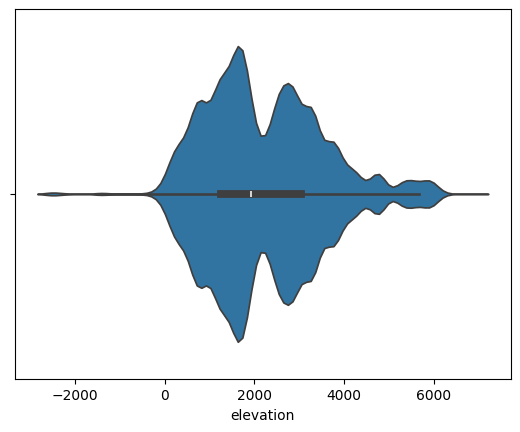

In [ ]:
# Membuat boxplot untuk kolom 'Elevation'
sns.violinplot(x=df['elevation'])
plt.show()

In [ ]:
gunung_dibawah_laut = df[df['elevation'] < 0]
gunung_dibawah_laut[['volcano_name', 'primary_volcano_type', 'elevation']].head(10)

,volcano_name,primary_volcano_type,elevation
163,Northern EPR at 9.8°N,Submarine,-2500.0
164,Northern EPR at 9.8°N,Submarine,-2500.0
165,Northern EPR at 9.8°N,Submarine,-2500.0
166,Northern EPR at 9.8°N,Submarine,-2500.0
167,Northern EPR at 9.8°N,Submarine,-2500.0
168,Northern EPR at 9.8°N,Submarine,-2500.0
169,Northern EPR at 9.8°N,Submarine,-2500.0
170,Northern EPR at 9.8°N,Submarine,-2500.0
171,Galapagos Rift,Submarine,-2430.0
172,Galapagos Rift,Submarine,-2430.0


In [ ]:
total_minus = (df['elevation'] < 0).sum()
print("Jumlah baris yang minus:", total_minus)


Jumlah baris yang minus: 216


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31035 entries, 0 to 31034
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   volcano_number            31035 non-null  int64  
 1   volcano_name              31035 non-null  object 
 2   eruption_number           31035 non-null  int64  
 3   eruption_start_year       31035 non-null  int64  
 4   event_number              31035 non-null  int64  
 5   event_type                31035 non-null  object 
 6   eruption_category         31035 non-null  object 
 7   vei                       31035 non-null  float64
 8   region                    31035 non-null  object 
 9   primary_volcano_type      31035 non-null  object 
 10  tectonic_settings         31035 non-null  object 
 11  elevation                 31035 non-null  float64
 12  major_rock_1              31035 non-null  object 
 13  major_rock_2              24451 non-null  object 
 14  major_

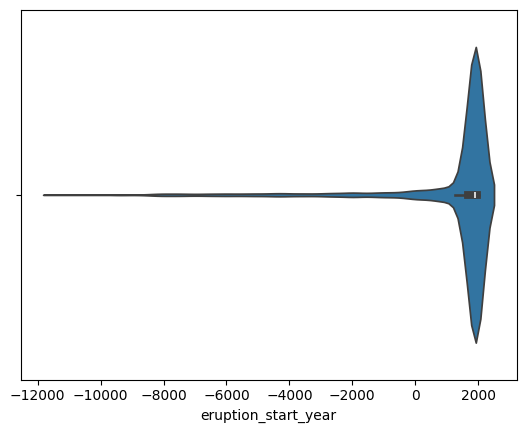

In [ ]:
sns.violinplot(x=df['eruption_start_year'])
plt.show()

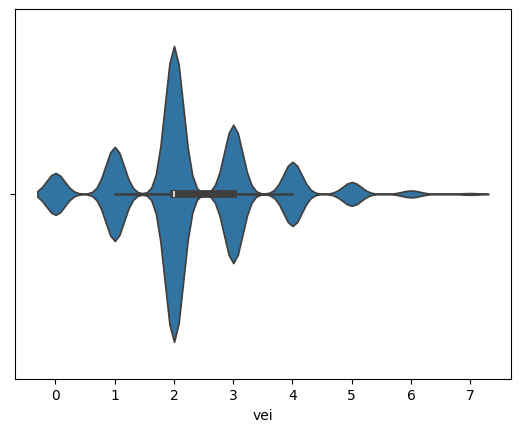

In [ ]:
sns.violinplot(x=df['vei'])
plt.show()

In [ ]:
df.duplicated().sum()

np.int64(0)

#### 3.3. Inconsistency Value??

/tmp/ipykernel_2912/3204048932.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], x='vei', data=df, palette='viridis')


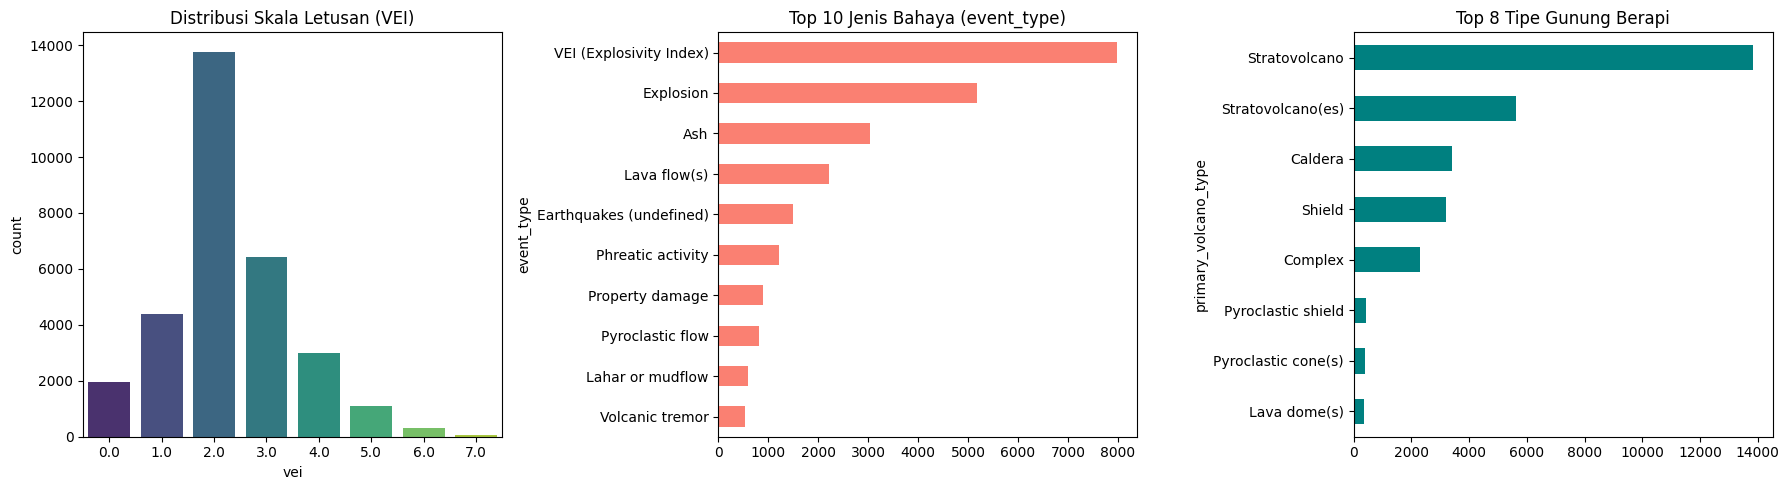

In [131]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Sebaran VEI
sns.countplot(ax=axes[0], x='vei', data=df, palette='viridis')
axes[0].set_title('Distribusi Skala Letusan (VEI)')

# 2. Top 10 Event Type
df['event_type'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Top 10 Jenis Bahaya (event_type)')
axes[1].invert_yaxis()

# 3. Top 8 Tipe Gunung
df['primary_volcano_type'].value_counts().head(8).plot(kind='barh', ax=axes[2], color='teal')
axes[2].set_title('Top 8 Tipe Gunung Berapi')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

In [135]:
sorted(df['primary_volcano_type'].unique())

['Caldera',
 'Caldera(s)',
 'Complex',
 'Complex(es)',
 'Compound',
 'Crater rows',
 'Fissure vent(s)',
 'Lava cone',
 'Lava dome',
 'Lava dome(s)',
 'Maar(s)',
 'Pyroclastic cone',
 'Pyroclastic cone(s)',
 'Pyroclastic shield',
 'Shield',
 'Shield(s)',
 'Stratovolcano',
 'Stratovolcano(es)',
 'Stratovolcano?',
 'Subglacial',
 'Submarine',
 'Tuff cone(s)',
 'Volcanic field']